<a href="https://colab.research.google.com/github/howonJeong/Journey_to_TinyLLAMA/blob/main/Step1_MitDeep/1.7.2_TwoLayerNet_with_Bckprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/WegraLee/deep-learning-from-scratch.git

import sys, os
sys.path.append('/content/deep-learning-from-scratch')

Cloning into 'deep-learning-from-scratch'...
remote: Enumerating objects: 1118, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 1118 (delta 142), reused 129 (delta 129), pack-reused 943 (from 2)
Receiving objects: 100% (1118/1118), 52.68 MiB | 21.86 MiB/s, done.
Resolving deltas: 100% (645/645), done.


In [2]:
import numpy as np
from common.layers import *
from common.gradient import numerical_gradient
from collections import OrderedDict

순서가 있는 딕셔너리 - OrderedDict - 를 사용하면 Layer 집어넣을 때 편리함!

In [3]:
class TwoLayerNet:
  def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.001):
    self.params = {}

    self.params['W1']  = weight_init_std * np.random.randn(input_size, hidden_size)
    self.params['W2']  = weight_init_std * np.random.randn(hidden_size, output_size)
    self.params['b1'] = np.zeros(hidden_size)
    self.params['b2'] = np.zeros(output_size)

    self.layers = OrderedDict()
    self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
    self.layers['Relu'] = Relu()
    self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])

    self.LastLayer = SoftmaxWithLoss()

  def predict(self, x):
    for layer in self.layers.values():
      x = layer.forward(x)
    #재활용

    return x

  def loss(self, x, t):
    y = self.predict(x)
    return self.LastLayer.forward(y, t)

  def accuracy(self, x, t):
    y = self.predict(x)

    y = np.argmax(y, axis=1)
    #print(y.shape())
    #배치 사이즈와 클래스 수, axis = 1은 가로 (한 배치 내 모든 클래스)

    if t.ndim != 1 : t = np.argmax(t, axis=1)
    # 원 핫 인코딩이면 (2차원) 1차원 숫자레이블로 변환

    accuracy = np.sum(y == t) / float(x.shape[0])

    return accuracy

  def gradient(self, x, t):
    self.loss(x,t)

    dout = 1
    dout = self.LastLayer.backward(dout)

    layers = list(self.layers.values())
    layers.reverse() #역전파니까..

    for layer in layers:
      dout = layer.backward(dout)

    grads = {}
    grads['W1'] = self.layers['Affine1'].dW
    grads['b1'] = self.layers['Affine1'].db
    grads['W2'] = self.layers['Affine2'].dW
    grads['b2'] = self.layers['Affine2'].db

    return grads

기존 학습/추론 코드에서 그라디언트 부분만 수정

In [7]:
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)
network = TwoLayerNet(input_size=28*28, hidden_size=50, output_size=10)

train_loss_list = [] # This will now store epoch-wise train loss
train_acc_list = []
test_acc_list = []
test_loss_list = [] # Initialize test loss list

iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

iter_per_epoch = max(train_size / batch_size, 1)


for i in range(iters_num):
  batch_mask = np.random.choice(train_size, batch_size)
  x_batch = x_train[batch_mask]
  t_batch = t_train[batch_mask]

  grad = network.gradient(x_batch, t_batch)
  #여기..

  for key in ('W1', 'b1', 'W2', 'b2'):
    network.params[key] -= learning_rate * grad[key]

  # Calculate loss for the current batch
  # The 'loss' variable here is the batch loss, which will be appended if it's an epoch checkpoint
  loss = network.loss(x_batch, t_batch)

  if i % iter_per_epoch == 0:
    train_acc = network.accuracy(x_train, t_train)
    test_acc = network.accuracy(x_test, t_test)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    # Append the loss values at epoch intervals as well
    train_loss_list.append(loss) # Use the batch loss from this iteration as the epoch's train loss sample
    test_loss = network.loss(x_test, t_test) # Calculate test loss for the epoch
    test_loss_list.append(test_loss)

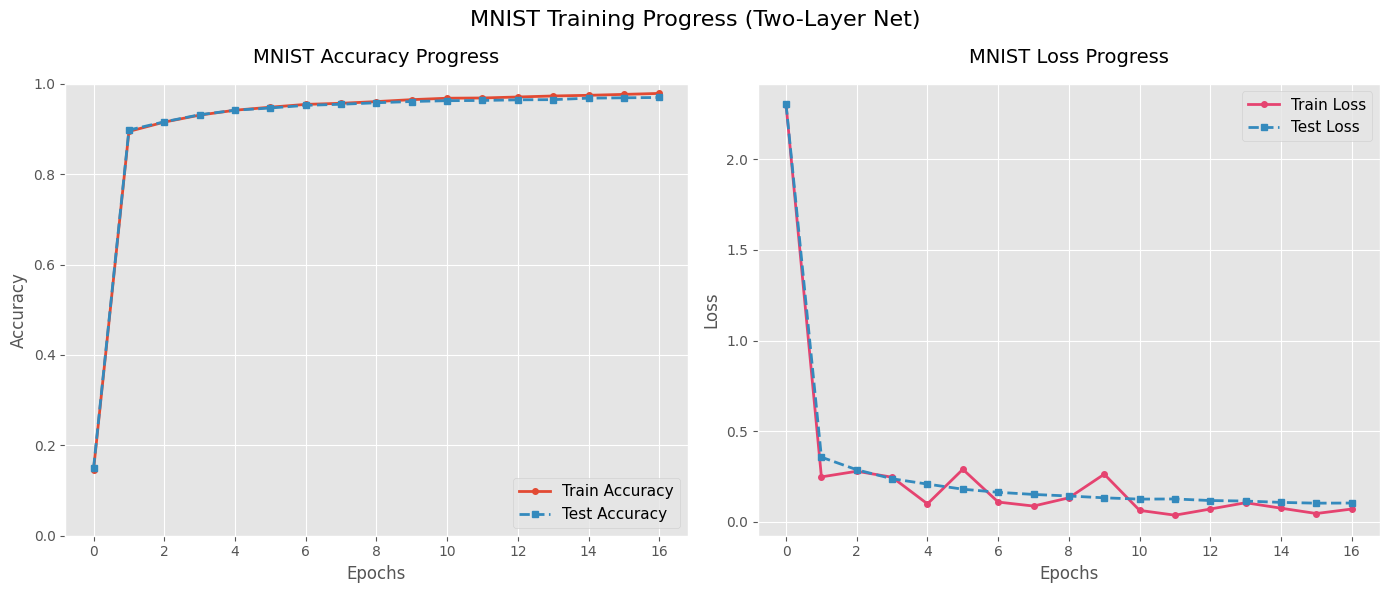

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')
plt.figure(figsize=(14, 6))

epochs = np.arange(len(train_acc_list))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc_list, label='Train Accuracy', marker='o', markersize=4, linewidth=2)
plt.plot(epochs, test_acc_list, label='Test Accuracy', linestyle='--', marker='s', markersize=4, linewidth=2)

plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("MNIST Accuracy Progress", fontsize=14, pad=15)
plt.ylim(0, 1.0)
plt.legend(loc='lower right', fontsize=11)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss_list, label='Train Loss', color='#e54370', marker='o', markersize=4, linewidth=2)
plt.plot(epochs, test_loss_list, label='Test Loss', color='#348abd', linestyle='--', marker='s', markersize=4, linewidth=2)

plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("MNIST Loss Progress", fontsize=14, pad=15)

plt.legend(loc='upper right', fontsize=11)

plt.suptitle("MNIST Training Progress (Two-Layer Net)", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()